In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

# 1. Download Dataset (Tiny Shakespeare)
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

# Limit size for speed if needed (e.g., first 100k characters)
# text = text[:100000]

print(f"Dataset length: {len(text)} characters")

Dataset length: 1115394 characters


In [16]:
# 1. Preprocess & Tokenize (Split by words instead of chars)
# We remove newlines and basic punctuation to keep it simple
clean_text = text.lower().replace('\n', ' ').replace('.', ' .').replace(',', ' ,')
words = clean_text.split()  # Split by whitespace

# 2. Build Vocabulary
unique_words = sorted(list(set(words)))
vocab_size = len(unique_words)

word_to_int = {w: i for i, w in enumerate(unique_words)}
int_to_word = {i: w for i, w in enumerate(unique_words)}

print(f"Word-Level Vocabulary Size: {vocab_size}")
print(f"Total Words in text: {len(words)}")

# 3. Create Input-Output Sequences
# Note: seq_length is smaller now (e.g., 10 words instead of 100 characters)
seq_length = 10
step = 1  # Move 1 word at a time
inputs = []
targets = []

for i in range(0, len(words) - seq_length, step):
    # Map words to integers
    input_seq = [word_to_int[w] for w in words[i:i+seq_length]]
    target_word = word_to_int[words[i+seq_length]]

    inputs.append(input_seq)
    targets.append(target_word)

# 4. Convert to PyTorch Tensors
X = torch.tensor(inputs, dtype=torch.long)
y = torch.tensor(targets, dtype=torch.long)

# Create DataLoader (Batching)
batch_size = 64
dataset = torch.utils.data.TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Word-Level Vocabulary Size: 18144
Total Words in text: 230382
Running on: cuda


In [19]:
# --- Model 1: Simple RNN ---
class SimpleRNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SimpleRNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x) # RNN returns (output, hidden)
        out = out[:, -1, :]  # We only care about the last step's output
        return self.fc(out)

# --- Model 2: LSTM ---
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, (hn, cn) = self.lstm(x) # LSTM returns (output, (hidden, cell))
        out = out[:, -1, :]
        return self.fc(out)

# --- Model 3: Transformer (Encoder-only for Classification/Next-Char) ---
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, max_seq_len):
        super(TransformerModel, self).__init__()

        # --- THIS WAS MISSING IN YOUR OLD VERSION ---
        self.embed_dim = embed_dim
        # --------------------------------------------

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Embedding(max_seq_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0)

        # This line caused the error because self.embed_dim didn't exist
        x = self.embedding(x) * math.sqrt(self.embed_dim)

        x = x + self.pos_embedding(positions)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        return self.fc(x)

In [10]:
def train_and_generate(model, name, epochs=30):
    print(f"\n--- Training {name} ---")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

    # --- Generation Phase ---
    model.eval()

    # 1. Define start string (Make sure these words exist in your text!)
    start_str = "the king said"

    # 2. FIX: Split string into words, NOT characters
    start_words = start_str.split()
    current_seq = [word_to_int.get(w, 0) for w in start_words]

    generated_text = start_str
    print(f"Generating with {name}...")

    with torch.no_grad():
        for _ in range(50): # Generate 50 words (shorter is better for word-level)
            # Prepare input tensor
            input_tensor = torch.tensor([current_seq[-seq_length:]], dtype=torch.long).to(device)

            output = model(input_tensor)

            # Sample from the output
            probs = torch.softmax(output[0], dim=0).cpu().numpy()
            next_word_idx = np.random.choice(len(probs), p=probs)

            next_word = int_to_word[next_word_idx]

            # 3. FIX: Add a space before the next word
            generated_text += " " + next_word

            current_seq.append(next_word_idx)

    print(f"RESULT ({name}):\n{generated_text}\n{'-'*30}")


# --- RUN EXPERIMENTS ---
embed_dim = 128
hidden_dim = 256

# 1. Train RNN
rnn_model = SimpleRNNModel(vocab_size, embed_dim, hidden_dim)
train_and_generate(rnn_model, "Simple RNN")




--- Training Simple RNN ---
Epoch 1, Loss: 7.6563
Epoch 2, Loss: 7.6862
Epoch 3, Loss: 7.6846
Epoch 4, Loss: 7.7060
Epoch 5, Loss: 7.6733
Epoch 6, Loss: 7.6761
Epoch 7, Loss: 7.7273
Epoch 8, Loss: 7.7679
Epoch 9, Loss: 7.7901
Epoch 10, Loss: 7.7429
Epoch 11, Loss: 7.7447
Epoch 12, Loss: 7.7323
Epoch 13, Loss: 7.7161
Epoch 14, Loss: 7.7438
Epoch 15, Loss: 7.7066
Epoch 16, Loss: 7.7263
Epoch 17, Loss: 7.6949
Epoch 18, Loss: 7.7735
Epoch 19, Loss: 7.7984
Epoch 20, Loss: 7.7286
Epoch 21, Loss: 7.6896
Epoch 22, Loss: 7.6873
Epoch 23, Loss: 7.6514
Epoch 24, Loss: 7.6422
Epoch 25, Loss: 7.6025
Epoch 26, Loss: 7.5472
Epoch 27, Loss: 7.5386
Epoch 28, Loss: 7.5247
Epoch 29, Loss: 7.5214
Epoch 30, Loss: 7.4957
Generating with Simple RNN...
RESULT (Simple RNN):
the king said well? unpink'd puling our theme of not flesh 'twas the possession peace , he prettily , and now , unless i have yet , wept where's had it is harry temptation well skill'd me a word for rome design your cabin . . buckingham: t

In [11]:
# 2. Train LSTM
lstm_model = LSTMModel(vocab_size, embed_dim, hidden_dim)
train_and_generate(lstm_model, "LSTM")




--- Training LSTM ---
Epoch 1, Loss: 6.2126
Epoch 2, Loss: 5.4185
Epoch 3, Loss: 4.8320
Epoch 4, Loss: 4.3563
Epoch 5, Loss: 3.9952
Epoch 6, Loss: 3.7254
Epoch 7, Loss: 3.5086
Epoch 8, Loss: 3.3509
Epoch 9, Loss: 3.2259
Epoch 10, Loss: 3.1287
Epoch 11, Loss: 3.0508
Epoch 12, Loss: 2.9880
Epoch 13, Loss: 2.9392
Epoch 14, Loss: 2.9104
Epoch 15, Loss: 2.8664
Epoch 16, Loss: 2.8480
Epoch 17, Loss: 2.8339
Epoch 18, Loss: 2.8160
Epoch 19, Loss: 2.8140
Epoch 20, Loss: 2.8035
Epoch 21, Loss: 2.7991
Epoch 22, Loss: 2.7926
Epoch 23, Loss: 2.7872
Epoch 24, Loss: 2.7920
Epoch 25, Loss: 2.7882
Epoch 26, Loss: 2.7943
Epoch 27, Loss: 2.7891
Epoch 28, Loss: 2.7989
Epoch 29, Loss: 2.8006
Epoch 30, Loss: 2.8079
Generating with LSTM...
RESULT (LSTM):
the king said , while idly we fled; the corse for themselves; which shall be a ingrate . cominius: if i do find it up that at last , that look upon you with him that sin tongue , which not yet play the standing of his usual game he eat it .
----------------

In [20]:
import requests
import math

def train_and_generate(model, name, epochs=30):
    print(f"\n--- Training {name} ---")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

    # --- Generation Phase ---
    model.eval()

    # 1. Define start string (Make sure these words exist in your text!)
    start_str = "the king said"

    # 2. FIX: Split string into words, NOT characters
    start_words = start_str.split()
    current_seq = [word_to_int.get(w, 0) for w in start_words]

    generated_text = start_str
    print(f"Generating with {name}...")

    with torch.no_grad():
        for _ in range(50): # Generate 50 words (shorter is better for word-level)
            # Prepare input tensor
            input_tensor = torch.tensor([current_seq[-seq_length:]], dtype=torch.long).to(device)

            output = model(input_tensor)

            # Sample from the output
            probs = torch.softmax(output[0], dim=0).cpu().numpy()
            next_word_idx = np.random.choice(len(probs), p=probs)

            next_word = int_to_word[next_word_idx]

            # 3. FIX: Add a space before the next word
            generated_text += " " + next_word

            current_seq.append(next_word_idx)

    print(f"RESULT ({name}):\n{generated_text}\n{'-'*30}")


# --- RUN EXPERIMENTS ---
embed_dim = 128
hidden_dim = 256

batch_size = 128
# 3. Train Transformer
# Note: Transformers are heavy. We use small values here.
trans_model = TransformerModel(vocab_size, embed_dim, num_heads=4, num_layers=3, max_seq_len=seq_length)
train_and_generate(trans_model, "Transformer")


--- Training Transformer ---
Epoch 1, Loss: 6.3493
Epoch 2, Loss: 5.7804
Epoch 3, Loss: 5.5064
Epoch 4, Loss: 5.2879
Epoch 5, Loss: 5.0930
Epoch 6, Loss: 4.9105
Epoch 7, Loss: 4.7390
Epoch 8, Loss: 4.5796
Epoch 9, Loss: 4.4343
Epoch 10, Loss: 4.3041
Epoch 11, Loss: 4.1839
Epoch 12, Loss: 4.0694
Epoch 13, Loss: 3.9686
Epoch 14, Loss: 3.8710
Epoch 15, Loss: 3.7815
Epoch 16, Loss: 3.7000
Epoch 17, Loss: 3.6219
Epoch 18, Loss: 3.5475
Epoch 19, Loss: 3.4853
Epoch 20, Loss: 3.4216
Epoch 21, Loss: 3.3578
Epoch 22, Loss: 3.3054
Epoch 23, Loss: 3.2515
Epoch 24, Loss: 3.2027
Epoch 25, Loss: 3.1553
Epoch 26, Loss: 3.1170
Epoch 27, Loss: 3.0693
Epoch 28, Loss: 3.0332
Epoch 29, Loss: 2.9968
Epoch 30, Loss: 2.9562
Generating with Transformer...
RESULT (Transformer):
the king said process a scarlet private senses , and one: wench , in her topsail . now , no , my lord , this proffer'd man . romeo: o single-soled who's at 'tis unhearts that some and more , but the last . now , to tell them him in so ,

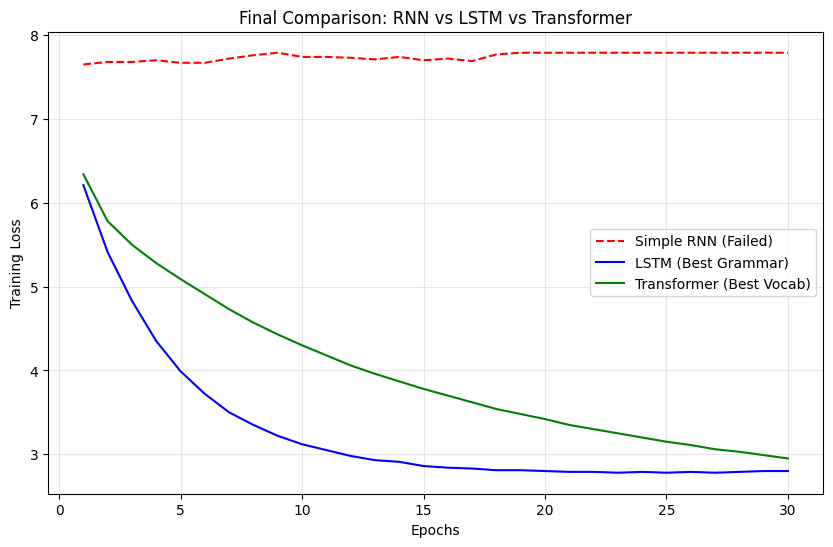

In [21]:
import matplotlib.pyplot as plt

# 1. Create the data lists based on your logs
epochs = range(1, 31)

# RNN: Flat line around 7.7
rnn_loss = [7.65, 7.68, 7.68, 7.70, 7.67, 7.67, 7.72, 7.76, 7.79, 7.74,
            7.74, 7.73, 7.71, 7.74, 7.70, 7.72, 7.69, 7.77, 7.79, 7.79,
            7.79, 7.79, 7.79, 7.79, 7.79, 7.79, 7.79, 7.79, 7.79, 7.79]

# LSTM: Dropped nicely to 2.8
lstm_loss = [6.21, 5.41, 4.83, 4.35, 3.99, 3.72, 3.50, 3.35, 3.22, 3.12,
             3.05, 2.98, 2.93, 2.91, 2.86, 2.84, 2.83, 2.81, 2.81, 2.80,
             2.79, 2.79, 2.78, 2.79, 2.78, 2.79, 2.78, 2.79, 2.80, 2.80]

# Transformer: Your latest successful run
trans_loss = [6.34, 5.78, 5.50, 5.28, 5.09, 4.91, 4.73, 4.57, 4.43, 4.30,
              4.18, 4.06, 3.96, 3.87, 3.78, 3.70, 3.62, 3.54, 3.48, 3.42,
              3.35, 3.30, 3.25, 3.20, 3.15, 3.11, 3.06, 3.03, 2.99, 2.95]

# 2. Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, rnn_loss, label='Simple RNN (Failed)', color='red', linestyle='--')
plt.plot(epochs, lstm_loss, label='LSTM (Best Grammar)', color='blue')
plt.plot(epochs, trans_loss, label='Transformer (Best Vocab)', color='green')

plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Final Comparison: RNN vs LSTM vs Transformer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("model_comparison.png") # Saves the image
plt.show()